# AI and Machine Learning in Prescriptive Workflows

This notebook is written for **business and analytics students**, not programmers. You are learning a **systems story**: how a forecast becomes an order quantity, and why a good-looking ML step can still create a bad decision downstream.

This notebook demonstrates how machine learning predictions feed into prescriptive analytics models — and where the combined pipeline can break down.

Understanding this is critical because:
- **ML models generate predictions** — demand forecasts, risk scores, churn probabilities
- **Prescriptive models consume those predictions** as inputs and recommend actions
- **The pipeline connects them:** Data → ML prediction → Optimization input → Decision recommendation
- **If the prediction is wrong, the recommendation can be confidently wrong** — the system is only as strong as the weakest handoff

**How to read this notebook:** treat the ML part as "pattern learning from history" and the optimization part as "choosing an order under costs and limits." The simulation at the end reconnects to Lessons 11.1–11.2.


## Key Concepts

**Where ML fits in the prescriptive pipeline:**  
ML often supplies **inputs** (forecasts) to an optimization model. It does not, by itself, decide what "optimal" means — humans choose objectives and constraints.

**The handoff problem:**  
If downstream optimization treats a forecast as **certain**, small forecast errors can become large operational mistakes (stockouts, waste, missed service levels).

**Best practice (illustrated here):**  
Treat the forecast as a **center** and carry an **uncertainty spread** into simulation, so you choose order quantities that balance holding vs stockout risk under realistic variability.

**What ML cannot do in a prescriptive workflow (still true in industry):**
- Decide ethical tradeoffs or define fairness
- Replace judgment about what should be optimized
- Guarantee explanations stakeholders will trust without validation


## Scenario: Weekly Grocery Store Inventory Optimization

A grocery chain uses a machine learning model to forecast weekly demand for a perishable product.
That forecast feeds into an inventory optimization model that determines how much to order.

**The pipeline:**
1. Historical sales data → ML demand forecast
2. Demand forecast → inventory optimization
3. Optimization → order recommendation

We will see what happens when the forecast is accurate, when it is off, and how passing forecast uncertainty into simulation improves the process.

## Step 1: Install Required Packages

**What you are doing:** installing `scikit-learn` for a simple regression forecast, `pulp` for the inventory optimization, plus plotting/table tools.

**Why so many libraries:** this notebook intentionally shows **three layers** (data, ML, optimization) in one place.


In [1]:
%pip install numpy matplotlib pandas scikit-learn pulp -q


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Step 2: Import Libraries

**What each import is for:**
- **`LinearRegression`**: a deliberately simple "learn a trend from history" model so the code stays readable
- **`pulp`**: builds the weekly ordering optimization with costs and constraints
- **`numpy` / `pandas` / `matplotlib`**: data generation, tables, plotting

**`np.random.seed(42)`** keeps the synthetic history repeatable.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from pulp import LpMinimize, LpProblem, LpVariable, value, PULP_CBC_CMD
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## Step 3: The Data Layer — Historical Sales

**Story:** before ML, you need histories. Here the notebook **simulates** 52 weeks that behave like real retail: trend, seasonality, and noise.

**What the code is doing:**
- `true_demand` builds a week-by-week demand series.
- `df_history` stores weeks and demand in a table.
- The plot is a sanity check: you should see a wiggly line that still has structure (not pure chaos).

**Teaching point:** prescriptive analytics is rarely "optimization only" — it sits on top of descriptive data reality.


=== HISTORICAL SALES DATA (last 10 weeks shown) ===
 week  actual_demand
   43            488
   44            483
   45            452
   46            470
   47            476
   48            512
   49            492
   50            438
   51            488
   52            468

Mean weekly demand: 434 units
Std dev:            46 units


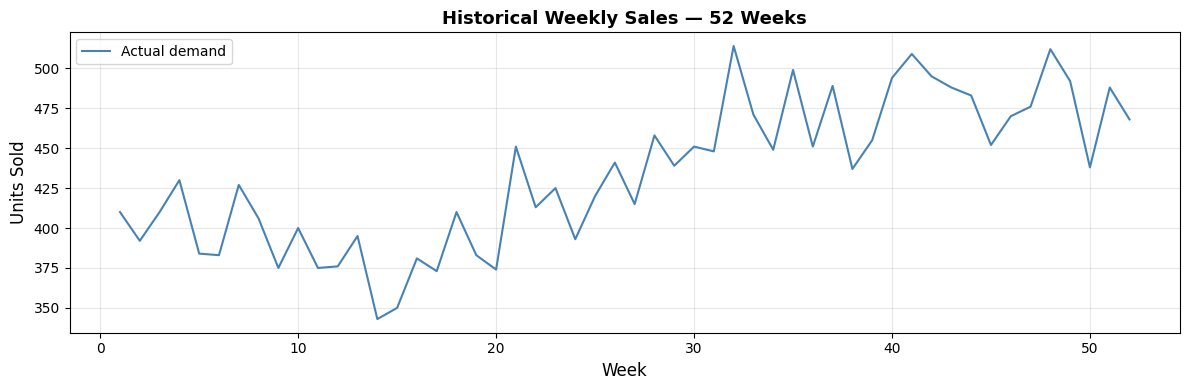

In [3]:
# === HISTORICAL SALES DATA ===
n_weeks = 52
weeks   = np.arange(1, n_weeks + 1)

# True underlying demand: upward trend + seasonal dip in summer
true_demand = (
    400
    + 1.5 * weeks
    - 30 * np.sin(2 * np.pi * weeks / 52)
    + np.random.normal(0, 25, n_weeks)
)
true_demand = np.clip(true_demand, 200, None)

df_history = pd.DataFrame({'week': weeks, 'actual_demand': true_demand.astype(int)})

print("=== HISTORICAL SALES DATA (last 10 weeks shown) ===")
print(df_history.tail(10).to_string(index=False))
print()
print(f"Mean weekly demand: {df_history['actual_demand'].mean():.0f} units")
print(f"Std dev:            {df_history['actual_demand'].std():.0f} units")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_history['week'], df_history['actual_demand'],
        color='steelblue', lw=1.5, label='Actual demand')
ax.set_xlabel('Week', fontsize=12)
ax.set_ylabel('Units Sold', fontsize=12)
ax.set_title('Historical Weekly Sales — 52 Weeks', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Step 4: The ML Layer — Demand Forecasting

**Story:** we train a simple model on weeks 1–48, then forecast future weeks. We also estimate uncertainty using **training residuals** (how wrong the model was on history).

**What the code is doing (plain English):**
- `LinearRegression().fit(...)` finds the best straight-line trend for demand vs week index.
- Residuals are **actual minus predicted** on the training period; their standard deviation becomes a simple "forecast noise" ruler.
- The loop prints a **point forecast** plus a wide approximate interval using `1.64 * sigma` (a standard normal shortcut for a rough 90% style band in teaching).

**After you run it:** notice that organizations often pass only the **point forecast** forward. The next steps show why that can be dangerous.


In [4]:
# === ML MODEL: DEMAND FORECASTING ===
X = df_history[['week']].values
y = df_history['actual_demand'].values

# Train on first 48 weeks; weeks 49-52 are hold-out
X_train, y_train = X[:48], y[:48]

ml_model = LinearRegression()
ml_model.fit(X_train, y_train)

# Estimate forecast uncertainty from training residuals
train_preds  = ml_model.predict(X_train)
residuals    = y_train - train_preds
forecast_std = residuals.std()

# Forecast weeks 53-56
future_weeks   = np.array([[53], [54], [55], [56]])
point_forecast = ml_model.predict(future_weeks).astype(int)

print("=== ML MODEL: DEMAND FORECAST ===")
print(f"Forecast uncertainty (1-sigma from training residuals): +/-{forecast_std:.0f} units")
print()
print(f"{'Week':>6} {'Point Forecast':>16} {'90% Interval':>20}")
print("-" * 44)
for i, w in enumerate([53, 54, 55, 56]):
    lo = int(point_forecast[i] - 1.64 * forecast_std)
    hi = int(point_forecast[i] + 1.64 * forecast_std)
    print(f"{w:>6} {point_forecast[i]:>16,}     [{lo:,} -- {hi:,}]")
print()
print("Most organizations pass only the point forecast downstream.")
print("We will show why that is a problem.")

=== ML MODEL: DEMAND FORECAST ===
Forecast uncertainty (1-sigma from training residuals): +/-28 units

  Week   Point Forecast         90% Interval
--------------------------------------------
    53              504     [458 -- 549]
    54              506     [460 -- 551]
    55              509     [463 -- 554]
    56              511     [465 -- 556]

Most organizations pass only the point forecast downstream.
We will show why that is a problem.


## Step 5: The Optimization Layer — Inventory Decision

**Story:** given a forecasted demand for week 53, the model chooses an order quantity to minimize expected weekly cost under a simplified cost structure, subject to a maximum order.

**What `optimize_order` is doing (conceptually):**
- Choose `order` (bounded by `max_order`)
- Track `held` inventory leftover and `unmet` demand shortfall
- Minimize purchasing cost + holding cost + stockout cost

**What to look for:** the optimizer will align tightly to the forecast you feed it — because it does not "know" the forecast might be wrong.


In [5]:
# === OPTIMIZATION MODEL ===
order_cost    = 2.00
holding_cost  = 0.80
stockout_cost = 5.00
max_order     = 800

def optimize_order(forecast_demand):
    model  = LpProblem('Inventory', LpMinimize)
    order  = LpVariable('order',  lowBound=0, upBound=max_order)
    held   = LpVariable('held',   lowBound=0)
    unmet  = LpVariable('unmet',  lowBound=0)
    model += order + unmet >= forecast_demand, 'Coverage'
    model += held == order - (forecast_demand - unmet), 'Balance'
    model += order_cost * order + holding_cost * held + stockout_cost * unmet
    model.solve(PULP_CBC_CMD(msg=0))
    return value(order)

week_53_forecast     = int(point_forecast[0])
order_point_forecast = optimize_order(week_53_forecast)

print("=== OPTIMIZATION RESULT (Point Forecast Only) ===")
print(f"Demand forecast fed to optimizer:  {week_53_forecast} units")
print(f"Recommended order quantity:        {order_point_forecast:.0f} units")
print()
print(f"The optimizer has no idea the forecast might be off by +/-{forecast_std:.0f} units.")
print("It recommends as if the forecast is fact.")

=== OPTIMIZATION RESULT (Point Forecast Only) ===
Demand forecast fed to optimizer:  504 units
Recommended order quantity:        504 units

The optimizer has no idea the forecast might be off by +/-28 units.
It recommends as if the forecast is fact.


## Step 6: The Handoff Problem

**Story:** this section is intentionally dramatic but realistic: the same recommended order is evaluated under several **true demand** levels.

**How to read the table:**
- **Held** is waste/carrying risk when you ordered too much
- **Unmet** is stockout exposure when you ordered too little
- **Total cost** combines ordering, holding, and stockout economics

**The lesson:** when demand comes in high, stockout costs can explode — even though the optimization step looked "optimal" given the forecast input.


In [6]:
print("=== WHAT IF THE FORECAST IS OFF? ===")
print(f"Optimizer recommended: {order_point_forecast:.0f} units (based on forecast of {week_53_forecast})")
print()

demand_scenarios = [
    ('Forecast accurate',   week_53_forecast),
    ('Demand 15% higher',   int(week_53_forecast * 1.15)),
    ('Demand 20% lower',    int(week_53_forecast * 0.80)),
    ('Demand 30% higher',   int(week_53_forecast * 1.30)),
]

print(f"{'Scenario':<25} {'Actual':>7} {'Ordered':>8} {'Held':>6} {'Unmet':>6} {'Total Cost':>12}")
print("-" * 68)
for name, actual in demand_scenarios:
    order  = int(order_point_forecast)
    sold   = min(order, actual)
    held   = max(0, order - actual)
    unmet  = max(0, actual - order)
    cost   = order_cost * order + holding_cost * held + stockout_cost * unmet
    print(f"{name:<25} {actual:>7,} {order:>8,} {held:>6,} {unmet:>6,} ${cost:>10,.2f}")
print()
print("Key observation: when demand is 30% higher than forecast, the optimizer's")
print("recommendation results in substantial stockout cost.")
print("The optimization model was not wrong — the forecast that fed it was wrong.")
print("Garbage in, garbage out still applies when AI is generating the 'garbage'.")

=== WHAT IF THE FORECAST IS OFF? ===
Optimizer recommended: 504 units (based on forecast of 504)

Scenario                   Actual  Ordered   Held  Unmet   Total Cost
--------------------------------------------------------------------
Forecast accurate             504      504      0      0 $  1,008.00
Demand 15% higher             579      504      0     75 $  1,383.00
Demand 20% lower              403      504    101      0 $  1,088.80
Demand 30% higher             655      504      0    151 $  1,763.00

Key observation: when demand is 30% higher than forecast, the optimizer's
recommendation results in substantial stockout cost.
The optimization model was not wrong — the forecast that fed it was wrong.
Garbage in, garbage out still applies when AI is generating the 'garbage'.


## Step 7: Better Practice — Pass Forecast Uncertainty to Simulation

**Story:** we treat week-53 demand as drawn from a bell-shaped distribution centered at the point forecast with spread from ML residuals. Then we compare several order quantities.

**What the code is doing:**
- Draw `n_scenarios` demand outcomes
- For each candidate order quantity, compute weekly costs across scenarios
- Plot mean cost vs P90 cost to show the **average vs tail** tradeoff
- Mark the order quantity that came from the point-forecast optimization as a reference line

**After you run it:** ask which order quantity you would choose if you fear stockouts more than holding extra inventory — and how that differs from choosing purely on mean cost.


=== SIMULATION OVER FORECAST UNCERTAINTY ===
ML forecast: 504 units +/- 28 units | Scenarios: 1,000

 Order Qty   Mean Cost   P90 Cost (tail)   % Stockouts
-------------------------------------------------------
       428 $ 1,242.57 $      1,423.90         99.9%
       478 $ 1,104.81 $      1,273.90         84.5%
       504 $ 1,073.62 $      1,195.90         52.2%
       554 $ 1,149.51 $      1,176.38          4.0%
       604 $ 1,287.00 $      1,315.11          0.1%


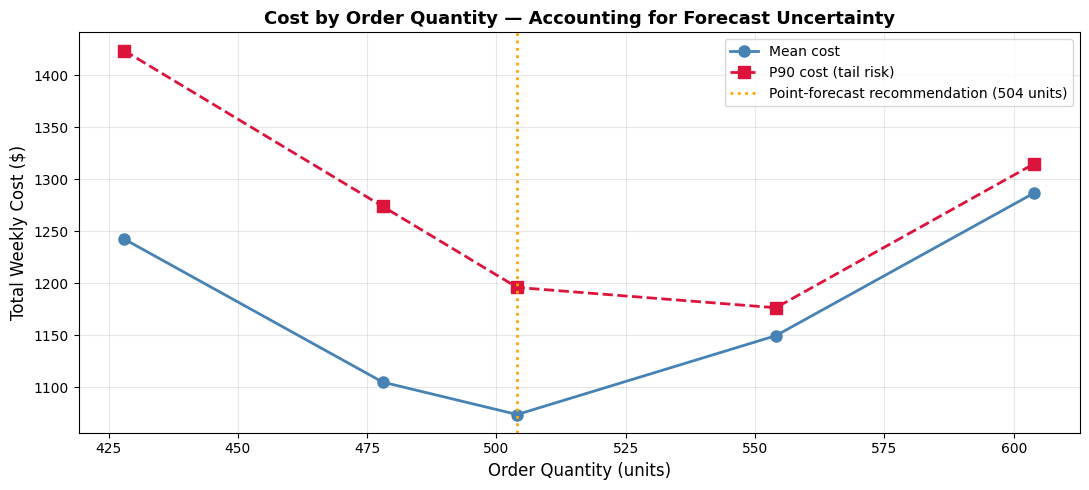


The optimal order depends on risk tolerance, not just the point forecast.
That judgment belongs to the manager, not the ML model.


In [7]:
# === BETTER PRACTICE: FORECAST + UNCERTAINTY => SIMULATION ===
n_scenarios = 1_000
demand_sim  = np.random.normal(week_53_forecast, forecast_std, n_scenarios)
demand_sim  = np.clip(demand_sim, 100, max_order + 200)

# Test multiple order quantities
order_qtys = [int(week_53_forecast * f) for f in [0.85, 0.95, 1.0, 1.10, 1.20]]
order_qtys = [min(q, max_order) for q in order_qtys]

sim_results = {}
for qty in order_qtys:
    held  = np.maximum(0, qty - demand_sim)
    unmet = np.maximum(0, demand_sim - qty)
    costs = order_cost * qty + holding_cost * held + stockout_cost * unmet
    sim_results[qty] = {
        'mean_cost':    np.mean(costs),
        'p90_cost':     np.percentile(costs, 90),
        'pct_stockout': np.mean(unmet > 0) * 100,
    }

print("=== SIMULATION OVER FORECAST UNCERTAINTY ===")
print(f"ML forecast: {week_53_forecast} units +/- {forecast_std:.0f} units | Scenarios: {n_scenarios:,}")
print()
print(f"{'Order Qty':>10} {'Mean Cost':>11} {'P90 Cost (tail)':>17} {'% Stockouts':>13}")
print("-" * 55)
for qty, r in sim_results.items():
    print(f"{qty:>10,} ${r['mean_cost']:>9,.2f} ${r['p90_cost']:>14,.2f}  {r['pct_stockout']:>11.1f}%")

# Visualize
fig, ax = plt.subplots(figsize=(11, 5))
qtys       = list(sim_results.keys())
mean_costs = [r['mean_cost']    for r in sim_results.values()]
p90_costs  = [r['p90_cost']     for r in sim_results.values()]
ax.plot(qtys, mean_costs, 'o-',  color='steelblue', lw=2, ms=8, label='Mean cost')
ax.plot(qtys, p90_costs,  's--', color='crimson',   lw=2, ms=8, label='P90 cost (tail risk)')
ax.axvline(order_point_forecast, color='orange', linestyle=':', lw=2,
           label=f'Point-forecast recommendation ({order_point_forecast:.0f} units)')
ax.set_xlabel('Order Quantity (units)', fontsize=12)
ax.set_ylabel('Total Weekly Cost ($)', fontsize=12)
ax.set_title('Cost by Order Quantity — Accounting for Forecast Uncertainty',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print()
print("The optimal order depends on risk tolerance, not just the point forecast.")
print("That judgment belongs to the manager, not the ML model.")

## Key Takeaways (Outro)

1. **ML + optimization is a real industrial pattern** — and it has a real failure mode: **treating predictions as facts**.

2. **Handoff errors propagate.** A decent forecast paired with the wrong certainty assumption can produce brittle decisions.

3. **End-to-end thinking beats local heroics.** Validating ML alone, or optimization alone, is not enough if the *connection* between them is wrong.

4. **Simulation is the bridge** between "forecast uncertainty" and "order policy risk" — same spirit as the first two Lesson 11 notebooks.

5. **ML still cannot define values.** Objectives, constraints, fairness, and accountability remain human responsibilities.

**Next notebook:** generative AI as a modeling partner — accelerating formulation, interpretation, and communication, with mandatory human validation.
